In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.signal import savgol_filter

## Финальный проект

Был реализован следующий пайплайн:
- Загрузка CSV-файлов
- Деление каждой реализации на окно признаков (4000 точек) и целевой вектор (1000 точек)
- Очистка входного сигнала фильтром Савицкого-Голея для подавления белого шума
- Обучение нейросети (MLP) на сглаженных признаках
- Расчет средней ошибки и RMS по ансамблю тестовых реализаций


### Загрузка данных

In [2]:
train_noisy = pd.read_csv('train.csv', header=None).values
train_clean = pd.read_csv('etalon_for_train.csv', header=None).values
test_noisy = pd.read_csv('test.csv', header=None).values
test_clean = pd.read_csv('etalon_for_test.csv', header=None).values

### Параметры

In [3]:
N_history = 4000
N_forecast = 1000
dt = 0.05

### Формирование выборки и применяем фильтр

In [4]:
X_train = train_noisy[:, :N_history]
Y_train = train_clean[:, N_history:]

X_test = test_noisy[:, :N_history]
Y_test_true = test_clean[:, N_history:]

In [5]:
X_train_smooth = savgol_filter(train_noisy[:, :4000], window_length=51, polyorder=3)
X_test_smooth = savgol_filter(test_noisy[:, :4000], window_length=51, polyorder=3)

### Препроцессинг

In [6]:
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train_smooth)
X_test_scaled = scaler_x.transform(X_test_smooth)

### Обучение модели (MLP)

In [7]:
model = MLPRegressor(hidden_layer_sizes=(200, 100),
                     activation='relu',
                     solver='adam',
                     max_iter=200,
                     verbose=True,
                     random_state=42)

model.fit(X_train_scaled, Y_train)

Iteration 1, loss = 0.16954183
Iteration 2, loss = 0.14405549
Iteration 3, loss = 0.13965034
Iteration 4, loss = 0.13813491
Iteration 5, loss = 0.13751260
Iteration 6, loss = 0.13687692
Iteration 7, loss = 0.13606251
Iteration 8, loss = 0.13482205
Iteration 9, loss = 0.13323164
Iteration 10, loss = 0.13086159
Iteration 11, loss = 0.12780713
Iteration 12, loss = 0.12403227
Iteration 13, loss = 0.11957680
Iteration 14, loss = 0.11448984
Iteration 15, loss = 0.10943696
Iteration 16, loss = 0.10412764
Iteration 17, loss = 0.09879525
Iteration 18, loss = 0.09403520
Iteration 19, loss = 0.08922909
Iteration 20, loss = 0.08477431
Iteration 21, loss = 0.08076658
Iteration 22, loss = 0.07741877
Iteration 23, loss = 0.07378141
Iteration 24, loss = 0.07093178
Iteration 25, loss = 0.06780816
Iteration 26, loss = 0.06542685
Iteration 27, loss = 0.06241480
Iteration 28, loss = 0.06029592
Iteration 29, loss = 0.05798165
Iteration 30, loss = 0.05619918
Iteration 31, loss = 0.05425401
Iteration 32, los

MLPRegressor(hidden_layer_sizes=(200, 100), random_state=42, verbose=True)

### Делаем прогноз

In [8]:
Y_pred = model.predict(X_test_scaled)

### Расчет метрик
  - Ошибка для каждой реализации k и каждого момента времени i
  - Среднее значение ошибки прогноза по множеству реализаций L=500

In [9]:
error_matrix = Y_pred - Y_test_true
mean_error = np.mean(error_matrix, axis=0)

Среднеквадратическая погрешность

In [10]:
rms_error = np.sqrt(np.mean((error_matrix - mean_error)**2, axis=0))

### Визуализация

<>:6: SyntaxWarning: invalid escape sequence '\D'
<>:6: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_35860/1895193140.py:6: SyntaxWarning: invalid escape sequence '\D'
  ax[0].set_title("Среднее значение ошибки прогноза $\Delta \\bar{u}(t_i)$")


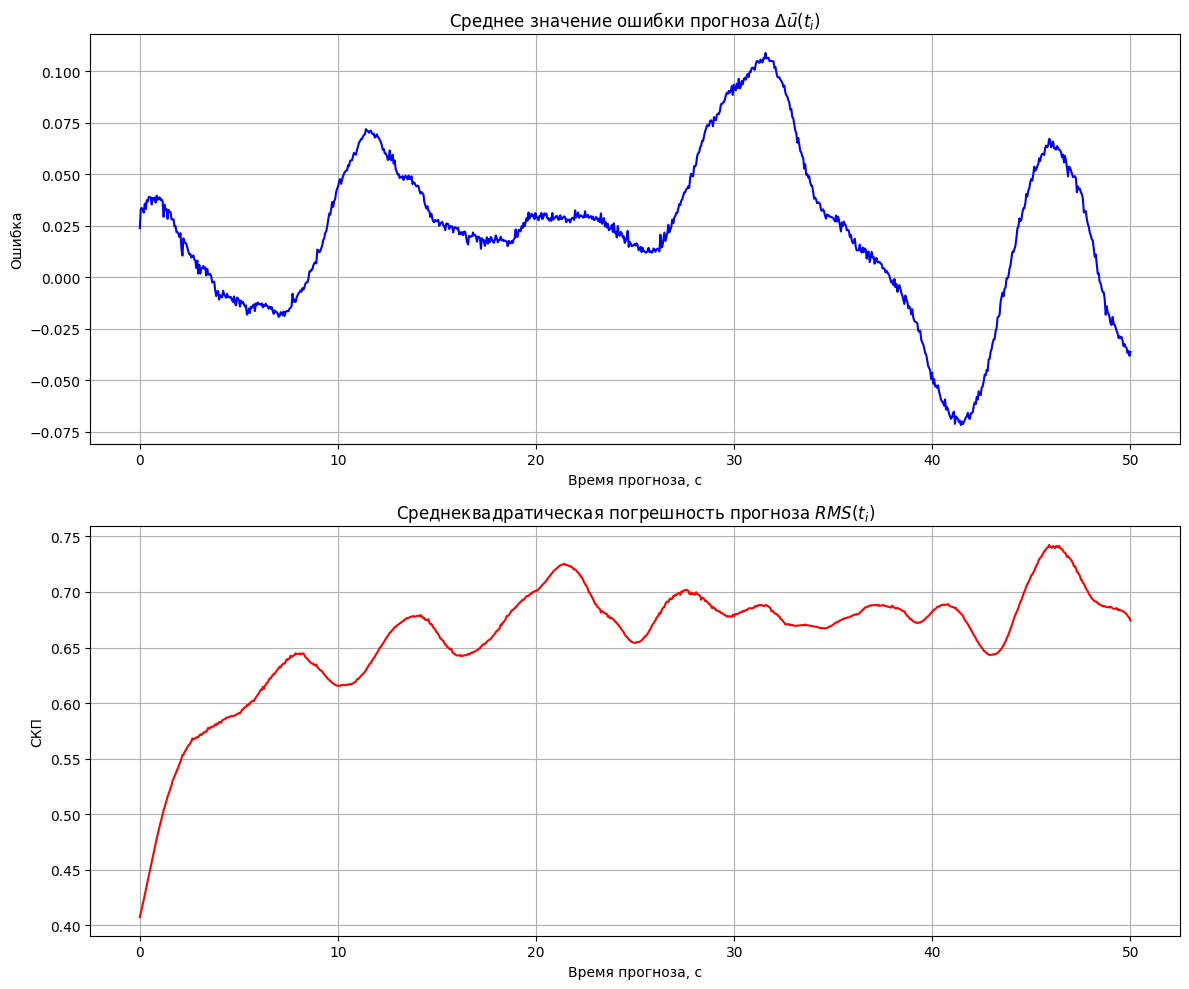

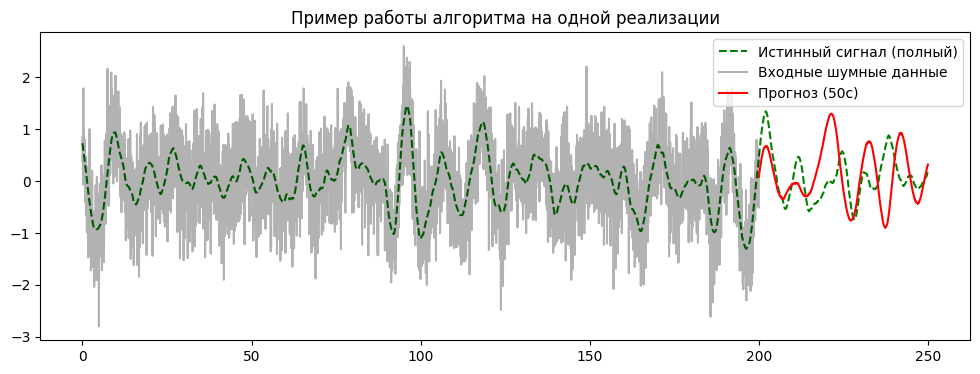

In [11]:
t_forecast = np.linspace(0, 50, N_forecast)

fig, ax = plt.subplots(2, 1, figsize=(12, 10))

ax[0].plot(t_forecast, mean_error, color='blue')
ax[0].set_title("Среднее значение ошибки прогноза $\Delta \\bar{u}(t_i)$")
ax[0].set_xlabel("Время прогноза, с")
ax[0].set_ylabel("Ошибка")
ax[0].grid(True)

ax[1].plot(t_forecast, rms_error, color='red')
ax[1].set_title("Среднеквадратическая погрешность прогноза $RMS(t_i)$")
ax[1].set_xlabel("Время прогноза, с")
ax[1].set_ylabel("СКП")
ax[1].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, 250, 5000), test_clean[0], 'g--', label='Истинный сигнал (полный)')
plt.plot(np.linspace(0, 200, 4000), test_noisy[0, :4000], 'k', alpha=0.3, label='Входные шумные данные')
plt.plot(np.linspace(200, 250, 1000), Y_pred[0], 'r', label='Прогноз (50с)')
plt.legend()
plt.title("Пример работы алгоритма на одной реализации")
plt.show()
